In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and CV
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    ParameterGrid,
    cross_val_predict
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("heart.csv")

print("Dataset loaded successfully!\n")

print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!

Dataset shape:
(918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# ==========================================
# DATASET INFO
# ==========================================

print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak        

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
# ==========================================
# FEATURES AND TARGET
# ==========================================

TARGET_COLUMN = "HeartDisease"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 11)
Target shape: (918,)


In [5]:
# ==========================================
# COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Numerical columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


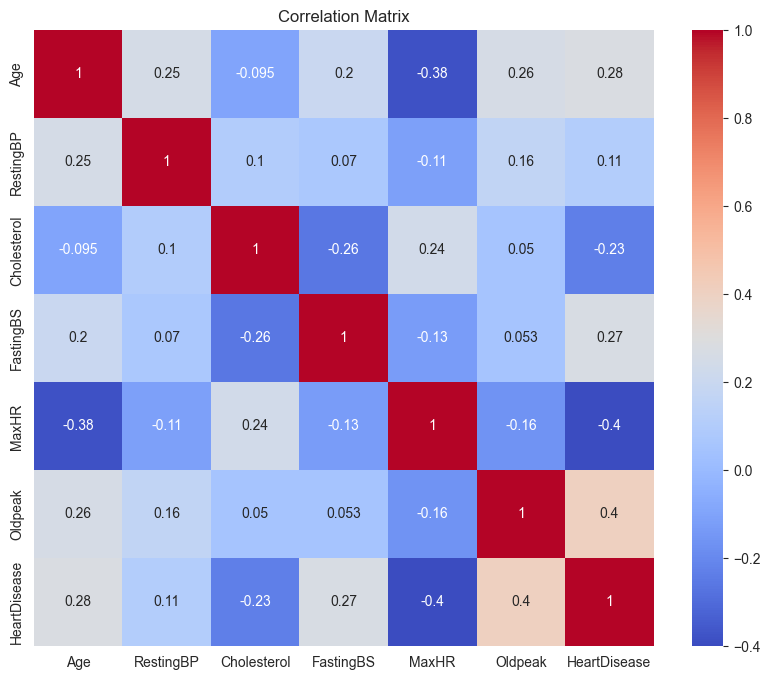

In [6]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [7]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (734, 11)
Testing set: (184, 11)


In [8]:
# ==========================================
# PREPROCESSING
# ==========================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_unscaled, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipelines created (scaled + unscaled).")

Preprocessing pipelines created (scaled + unscaled).


In [9]:
# ==========================================
# MODEL EVALUATION FUNCTION
# ==========================================

def evaluate_model(model, X_test, y_test, model_name="Model"):

    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred.astype(float)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n========== {model_name} ==========")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [10]:
# ==========================================
# FEATURE SELECTION WITH DECISION TREE
# ==========================================

# Pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# Train model
dt_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [11]:
# ==========================================
# GET FEATURE NAMES
# ==========================================

# Get transformed feature names
encoded_cat_features = dt_pipeline.named_steps[
    'preprocessor'
].named_transformers_['cat'].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([
    numerical_cols,
    encoded_cat_features
])

print("Total transformed features:", len(all_feature_names))

Total transformed features: 20


In [12]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = dt_pipeline.named_steps['clf'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_df.head(15))

,Feature,Importance
19,ST_Slope_Up,0.421219
4,MaxHR,0.123239
8,ChestPainType_ASY,0.087742
5,Oldpeak,0.078614
2,Cholesterol,0.074122
0,Age,0.065825
1,RestingBP,0.055960
3,FastingBS,0.019032
6,Sex_F,0.016010
7,Sex_M,0.015402


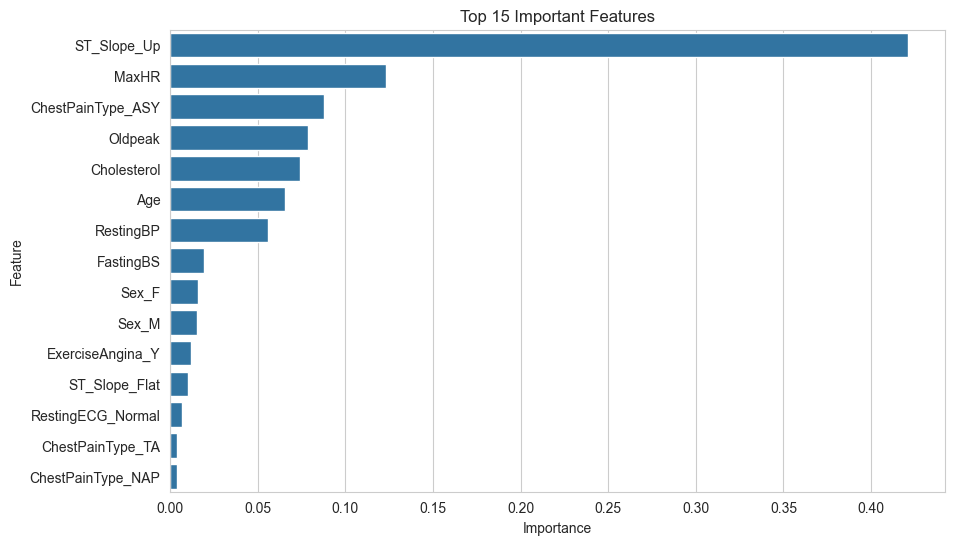

In [13]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [14]:
# ==========================================
# MOST IMPORTANT FEATURES
# ==========================================

print("Top 10 Most Important Features:\n")

for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']} --> {row['Importance']:.4f}")

Top 10 Most Important Features:

ST_Slope_Up --> 0.4212
MaxHR --> 0.1232
ChestPainType_ASY --> 0.0877
Oldpeak --> 0.0786
Cholesterol --> 0.0741
Age --> 0.0658
RestingBP --> 0.0560
FastingBS --> 0.0190
Sex_F --> 0.0160
Sex_M --> 0.0154


In [15]:
# ==========================================
# CROSS-VALIDATION SETUP
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

print("5-fold stratified cross-validation created.")

5-fold stratified cross-validation created.


Fitting 5 folds for each of 270 candidates, totalling 1350 fits


Best parameters:
{'clf__criterion': 'entropy', 'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}

Best CV F1 score:
0.843901623333233

Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8283
  CV F1 Score: 0.8437

CV Confusion Matrix:
[[268  60]
 [ 66 340]]


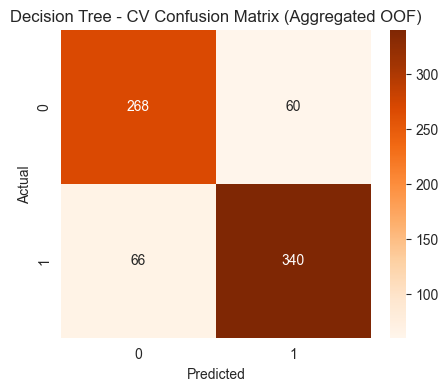

In [16]:
# ==========================================
# DECISION TREE - HYPERPARAMETER TUNING
# ==========================================

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_param_grid = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': [None, 'sqrt', 'log2']
}

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

print("\nBest CV F1 score:")
print(dt_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_dt = cross_val_predict(dt_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_dt):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_dt):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_dt))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_dt), annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== Decision Tree ==========
Accuracy : 0.8533
Precision: 0.9032
Recall   : 0.8235
F1 Score : 0.8615
AUC Score: 0.9244

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        82
           1       0.90      0.82      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



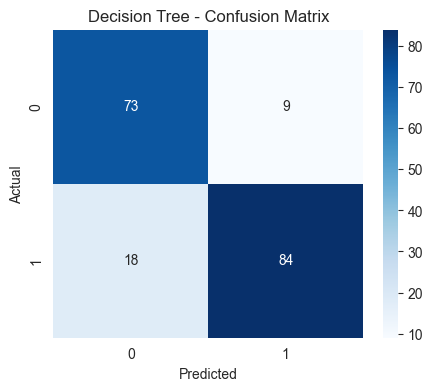

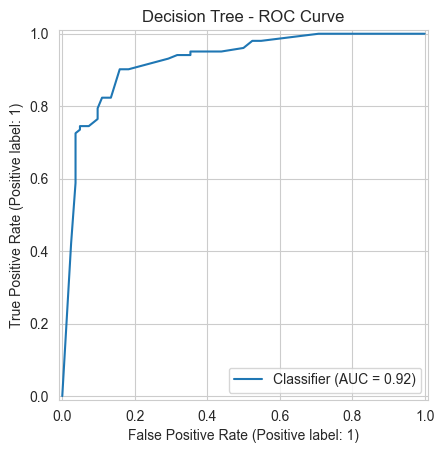

In [17]:
# ==========================================
# DECISION TREE - TEST EVALUATION
# ==========================================

best_dt = dt_grid.best_estimator_

dt_results = evaluate_model(
    best_dt,
    X_test,
    y_test,
    model_name="Decision Tree"
)

results.append(dt_results)

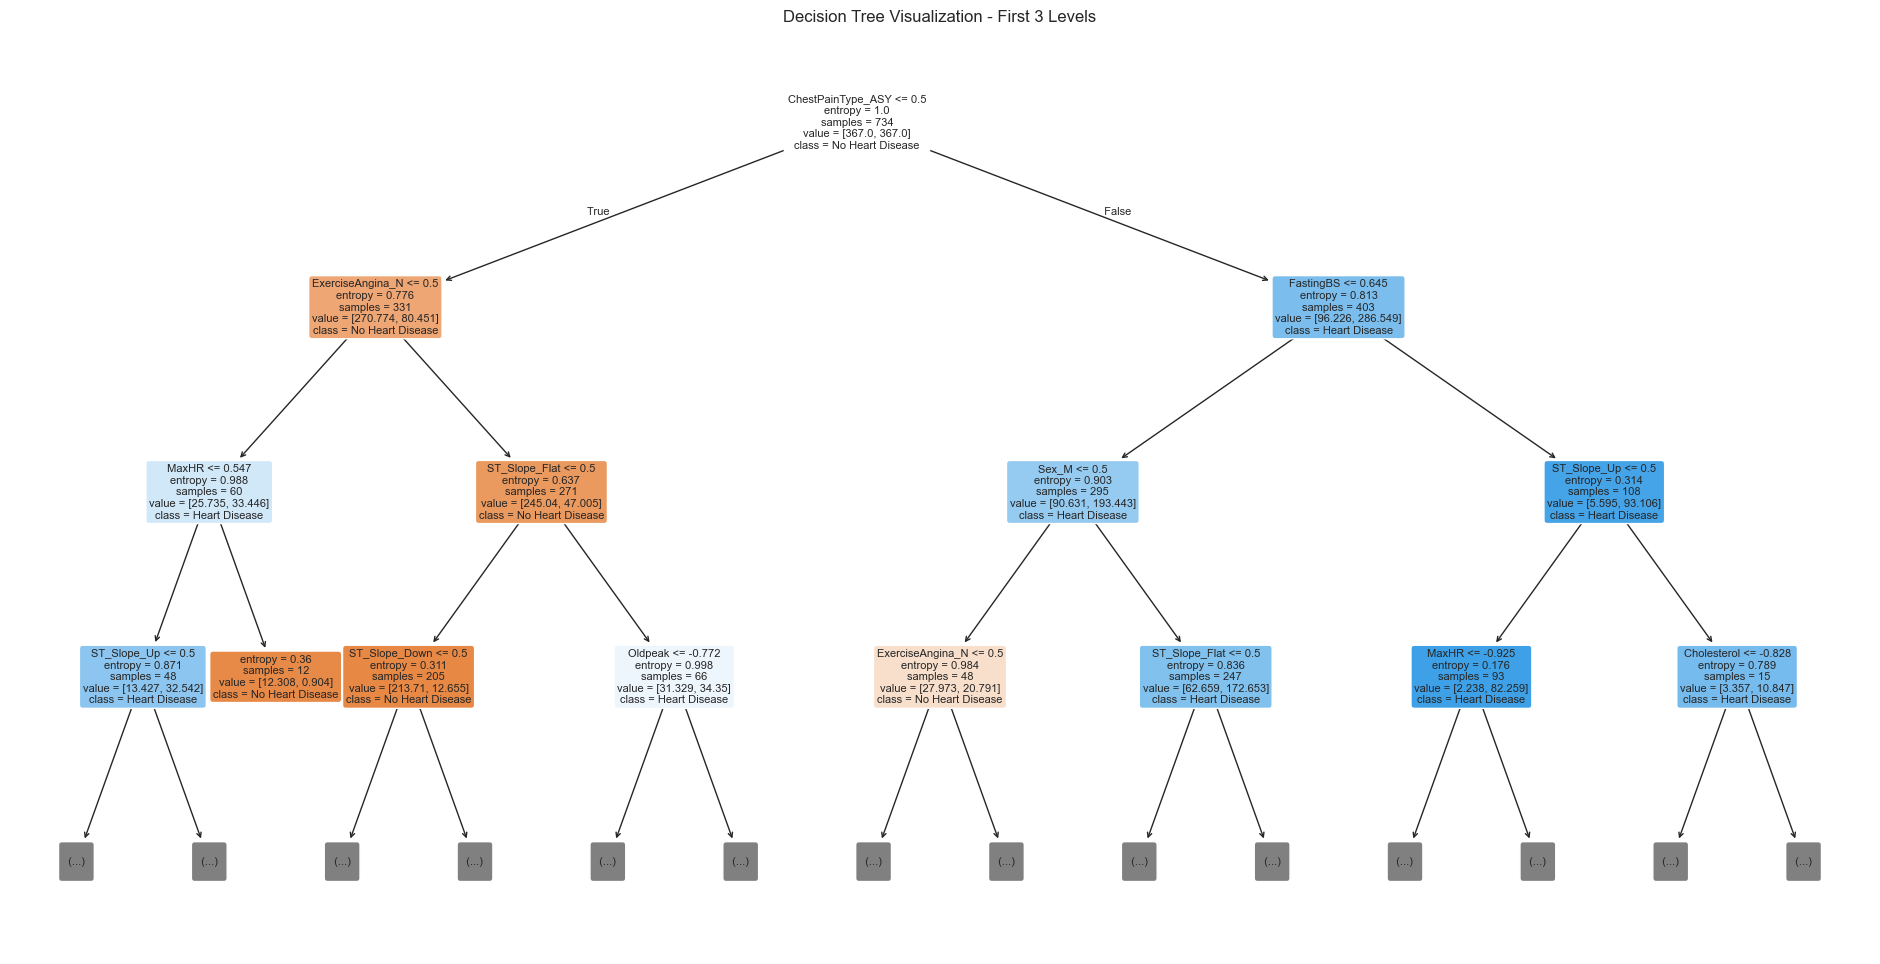

In [18]:
# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    best_dt.named_steps['clf'],
    feature_names=all_feature_names,
    class_names=['No Heart Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization - First 3 Levels")
plt.show()

In [19]:
# ==========================================
# DECISION TREE INTERPRETATION
# ==========================================

print("Decision Tree Summary")
print("---------------------")
print("Best parameters:", dt_grid.best_params_)
print(f"Best cross-validation F1 score: {dt_grid.best_score_:.4f}")
print(f"Test F1 score: {dt_results['F1']:.4f}")
print(f"Test AUC score: {dt_results['AUC']:.4f}")

Decision Tree Summary
---------------------
Best parameters: {'clf__criterion': 'entropy', 'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Best cross-validation F1 score: 0.8439
Test F1 score: 0.8615
Test AUC score: 0.9244


Feature Ranking Comparison: Task 1 vs Decision Tree


,Feature,Task1_Rank,DT_Importance,DT_Rank
0,ST_Slope,1,0.431374,1
1,MaxHR,5,0.123239,2
2,ChestPainType,2,0.096009,3
3,Oldpeak,4,0.078614,4
4,Cholesterol,11,0.074122,5
5,Age,6,0.065825,6
6,RestingBP,10,0.055960,7
7,Sex,7,0.031412,8
8,FastingBS,8,0.019032,9
9,RestingECG,9,0.012404,10


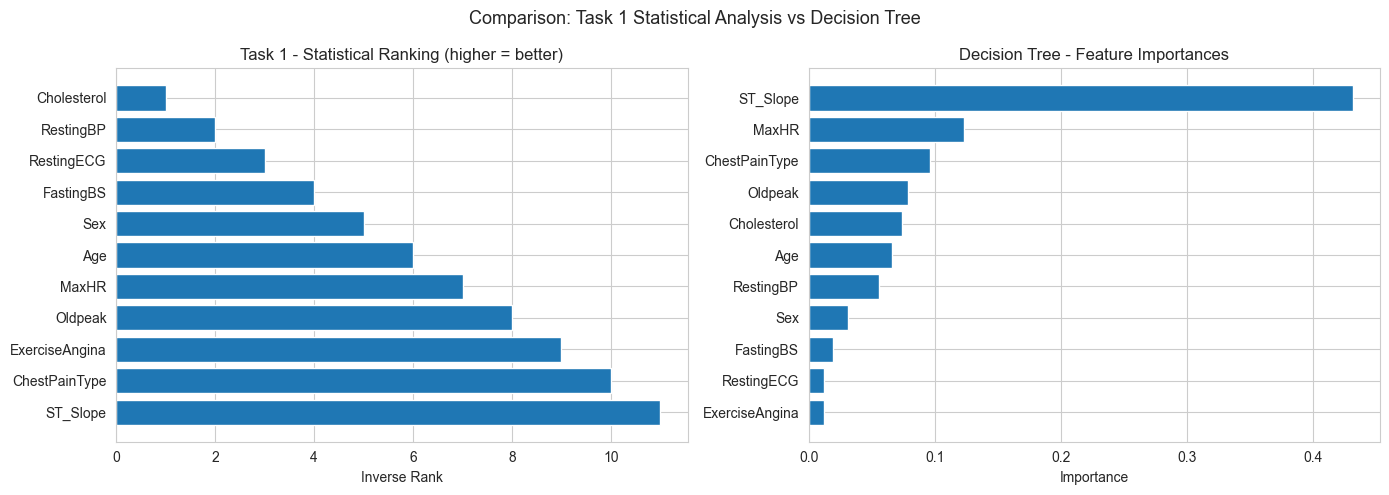


Both methods agree that ST_Slope, ChestPainType, MaxHR and Oldpeak
are among the most predictive features for heart disease.


In [20]:
# ==========================================
# DT - COMPARATIVE STUDY WITH TASK 1 (HW1)
# ==========================================
# Task 1 (Exercise 3) ranked predictive power using:
#   Categorical (Cramer's V): ST_Slope > ChestPainType > ExerciseAngina > Sex > RestingECG
#   Numerical (Point-Biserial |r|): Oldpeak > MaxHR > Age > RestingBP > Cholesterol > FastingBS

task1_ranking = {
    'ST_Slope': 1, 'ChestPainType': 2, 'ExerciseAngina': 3,
    'Oldpeak': 4, 'MaxHR': 5, 'Age': 6, 'Sex': 7,
    'FastingBS': 8, 'RestingECG': 9, 'RestingBP': 10, 'Cholesterol': 11
}

# Aggregate DT importances by original feature (sum one-hot columns)
dt_orig_imp = {}
for feat in task1_ranking:
    mask = [f.startswith(feat) for f in all_feature_names]
    dt_orig_imp[feat] = importances[mask].sum()

comp_df = pd.DataFrame([
    {'Feature': f, 'Task1_Rank': r, 'DT_Importance': dt_orig_imp[f]}
    for f, r in task1_ranking.items()
]).sort_values('DT_Importance', ascending=False).reset_index(drop=True)
comp_df['DT_Rank'] = range(1, len(comp_df)+1)

print("Feature Ranking Comparison: Task 1 vs Decision Tree")
display(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comp_sorted = comp_df.sort_values('Task1_Rank')
axes[0].barh(comp_sorted['Feature'],
             comp_sorted['Task1_Rank'].max() + 1 - comp_sorted['Task1_Rank'])
axes[0].set_title("Task 1 - Statistical Ranking (higher = better)")
axes[0].set_xlabel("Inverse Rank")

comp_sorted2 = comp_df.sort_values('DT_Importance')
axes[1].barh(comp_sorted2['Feature'], comp_sorted2['DT_Importance'])
axes[1].set_title("Decision Tree - Feature Importances")
axes[1].set_xlabel("Importance")

plt.suptitle("Comparison: Task 1 Statistical Analysis vs Decision Tree", fontsize=13)
plt.tight_layout()
plt.show()

print("\nBoth methods agree that ST_Slope, ChestPainType, MaxHR and Oldpeak")
print("are among the most predictive features for heart disease.")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


Best parameters:
{'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}

Best CV F1 score:
0.8830692686517029



Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8678
  CV F1 Score: 0.8824

CV Confusion Matrix:
[[273  55]
 [ 42 364]]


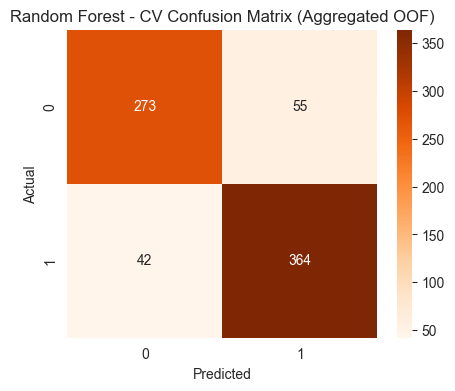

In [21]:
# ==========================================
# RANDOM FOREST - HYPERPARAMETER TUNING
# ==========================================

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1 score:")
print(rf_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_rf = cross_val_predict(rf_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_rf):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_rf):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_rf))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_rf), annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== Random Forest ==========
Accuracy : 0.9022
Precision: 0.8962
Recall   : 0.9314
F1 Score : 0.9135
AUC Score: 0.9314

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



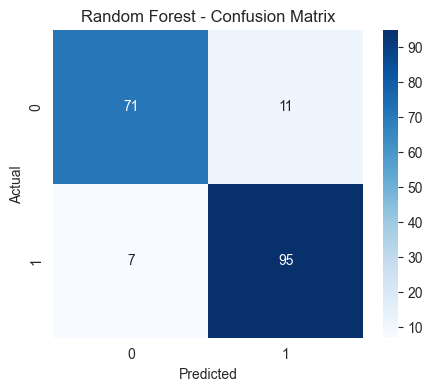

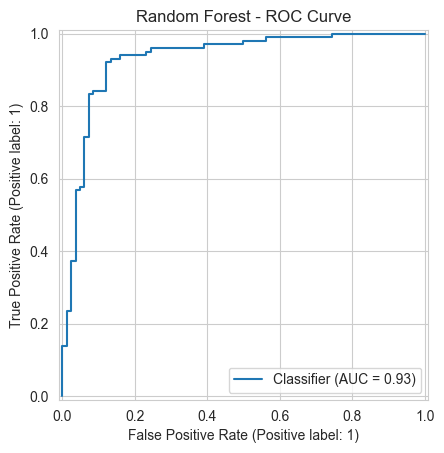

In [22]:
# ==========================================
# RANDOM FOREST - TEST EVALUATION
# ==========================================

best_rf = rf_grid.best_estimator_

rf_results = evaluate_model(
    best_rf,
    X_test,
    y_test,
    model_name="Random Forest"
)

results.append(rf_results)

In [23]:
# ==========================================
# RANDOM FOREST - FEATURE IMPORTANCE
# ==========================================

rf_importances = best_rf.named_steps['clf'].feature_importances_

rf_feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importances
})

rf_feature_importance_df = rf_feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(rf_feature_importance_df.head(15))

,Feature,Importance
19,ST_Slope_Up,0.224278
18,ST_Slope_Flat,0.147425
8,ChestPainType_ASY,0.124364
15,ExerciseAngina_N,0.086032
5,Oldpeak,0.073643
16,ExerciseAngina_Y,0.069341
2,Cholesterol,0.058865
4,MaxHR,0.058831
0,Age,0.025190
6,Sex_F,0.022244


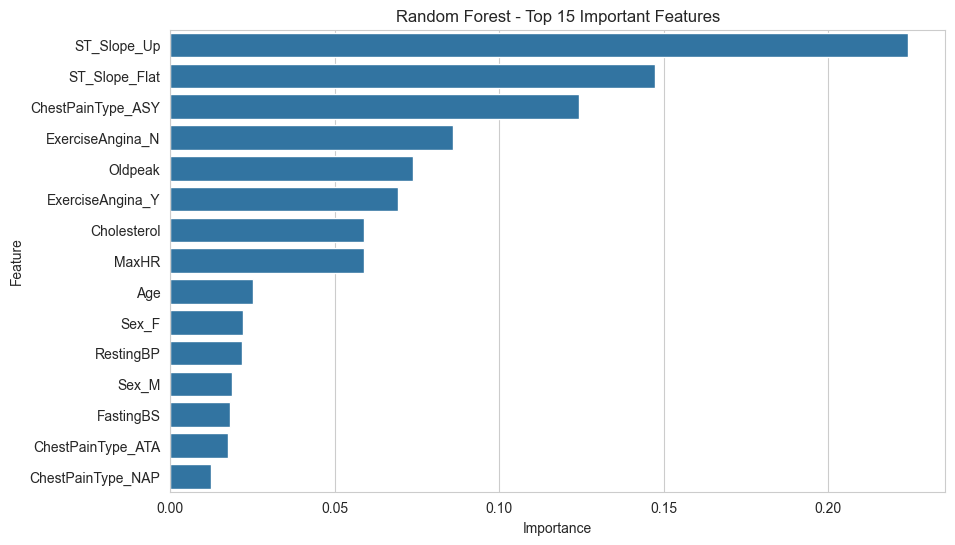

In [24]:
# ==========================================
# RANDOM FOREST - FEATURE IMPORTANCE PLOT
# ==========================================

top_rf_features = rf_feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rf_features,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest - Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [25]:
# ==========================================
# RANDOM FOREST INTERPRETATION
# ==========================================

print("Random Forest Summary")
print("---------------------")
print("Best parameters:", rf_grid.best_params_)
print(f"Best cross-validation F1 score: {rf_grid.best_score_:.4f}")
print(f"Test F1 score: {rf_results['F1']:.4f}")
print(f"Test AUC score: {rf_results['AUC']:.4f}")

print("\nTop 10 important features:")
for idx, row in rf_feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']} --> {row['Importance']:.4f}")

Random Forest Summary
---------------------
Best parameters: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Best cross-validation F1 score: 0.8831
Test F1 score: 0.9135
Test AUC score: 0.9314

Top 10 important features:
ST_Slope_Up --> 0.2243
ST_Slope_Flat --> 0.1474
ChestPainType_ASY --> 0.1244
ExerciseAngina_N --> 0.0860
Oldpeak --> 0.0736
ExerciseAngina_Y --> 0.0693
Cholesterol --> 0.0589
MaxHR --> 0.0588
Age --> 0.0252
Sex_F --> 0.0222


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters:
{'clf__var_smoothing': 1e-09}

Best CV F1 score:
0.8619710738602497

Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8488
  CV F1 Score: 0.8618

CV Confusion Matrix:
[[277  51]
 [ 60 346]]


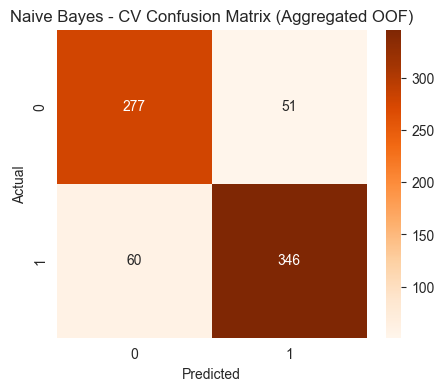

In [26]:
# ==========================================
# NAIVE BAYES - HYPERPARAMETER TUNING
# ==========================================

nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])

nb_param_grid = {
    'clf__var_smoothing': [
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

nb_grid = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train, y_train)

print("Best parameters:")
print(nb_grid.best_params_)

print("\nBest CV F1 score:")
print(nb_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_nb = cross_val_predict(nb_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_nb):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_nb):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_nb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_nb), annot=True, fmt='d', cmap='Oranges')
plt.title("Naive Bayes - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== Naive Bayes ==========
Accuracy : 0.8859
Precision: 0.8932
Recall   : 0.9020
F1 Score : 0.8976
AUC Score: 0.9118

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



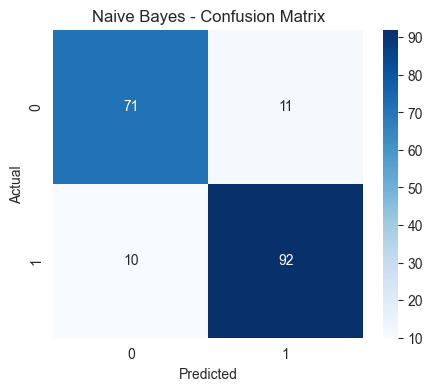

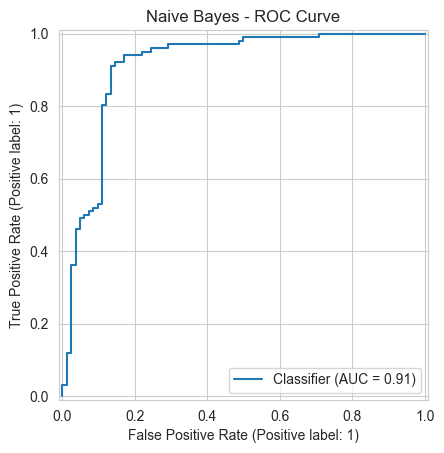

In [27]:
# ==========================================
# NAIVE BAYES - TEST EVALUATION
# ==========================================

best_nb = nb_grid.best_estimator_

nb_results = evaluate_model(
    best_nb,
    X_test,
    y_test,
    model_name="Naive Bayes"
)

results.append(nb_results)

In [28]:
# ==========================================
# NAIVE BAYES INTERPRETATION
# ==========================================

print("Naive Bayes Summary")
print("---------------------")
print("Best parameters:", nb_grid.best_params_)
print(f"Best cross-validation F1 score: {nb_grid.best_score_:.4f}")
print(f"Test F1 score: {nb_results['F1']:.4f}")
print(f"Test AUC score: {nb_results['AUC']:.4f}")

Naive Bayes Summary
---------------------
Best parameters: {'clf__var_smoothing': 1e-09}
Best cross-validation F1 score: 0.8620
Test F1 score: 0.8976
Test AUC score: 0.9118


In [29]:
# ==========================================
# kNN - IMPACT OF STANDARDIZATION
# ==========================================

from sklearn.base import clone

# Without standardization
knn_model_unscaled = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform'))
])
knn_grid_unscaled = GridSearchCV(knn_model_unscaled,
    {'clf__n_neighbors': [5]}, cv=cv, scoring='f1', n_jobs=-1)
knn_grid_unscaled.fit(X_train, y_train)
knn_f1_unscaled = knn_grid_unscaled.best_score_

# With standardization
knn_model_scaled = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform'))
])
knn_grid_scaled = GridSearchCV(knn_model_scaled,
    {'clf__n_neighbors': [5]}, cv=cv, scoring='f1', n_jobs=-1)
knn_grid_scaled.fit(X_train, y_train)
knn_f1_scaled = knn_grid_scaled.best_score_

print(f"kNN WITHOUT standardization - CV F1: {knn_f1_unscaled:.4f}")
print(f"kNN WITH standardization    - CV F1: {knn_f1_scaled:.4f}")
print(f"Impact: {knn_f1_scaled - knn_f1_unscaled:+.4f}")
print("\nStandardization equalizes feature scales, critical for distance-based methods.")

kNN WITHOUT standardization - CV F1: 0.7204
kNN WITH standardization    - CV F1: 0.8677
Impact: +0.1473

Standardization equalizes feature scales, critical for distance-based methods.


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best parameters:
{'clf__metric': 'manhattan', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}

Best CV F1 score:
0.8900919795062233

Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8747
  CV F1 Score: 0.8894

CV Confusion Matrix:
[[272  56]
 [ 36 370]]


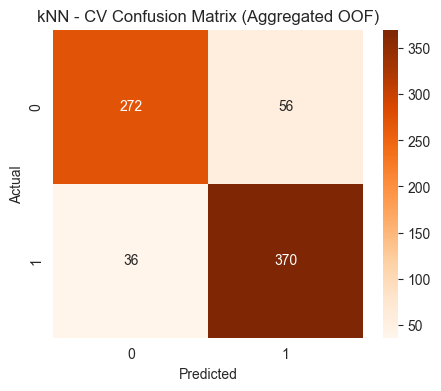

In [30]:
# ==========================================
# kNN - HYPERPARAMETER TUNING
# ==========================================

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__metric': ['euclidean', 'manhattan'],
    'clf__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

print("Best parameters:")
print(knn_grid.best_params_)

print("\nBest CV F1 score:")
print(knn_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_knn = cross_val_predict(knn_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_knn):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_knn):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_knn))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_knn), annot=True, fmt='d', cmap='Oranges')
plt.title("kNN - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== kNN ==========
Accuracy : 0.9293
Precision: 0.9320
Recall   : 0.9412
F1 Score : 0.9366
AUC Score: 0.9471

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        82
           1       0.93      0.94      0.94       102

    accuracy                           0.93       184
   macro avg       0.93      0.93      0.93       184
weighted avg       0.93      0.93      0.93       184



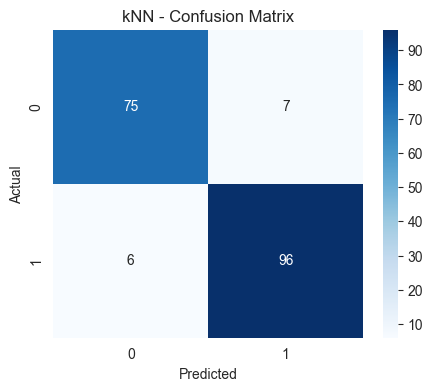

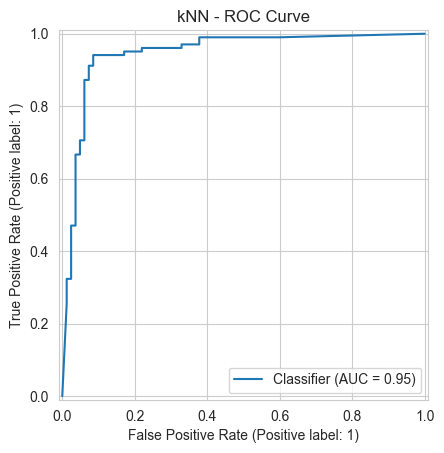


kNN Summary
-----------
Best parameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}
Best CV F1: 0.8901
Test F1: 0.9366
Test AUC: 0.9471


In [31]:
# ==========================================
# kNN - TEST EVALUATION
# ==========================================

best_knn = knn_grid.best_estimator_

knn_results = evaluate_model(
    best_knn, X_test, y_test, model_name="kNN"
)

results.append(knn_results)

print("\nkNN Summary")
print("-----------")
print("Best parameters:", knn_grid.best_params_)
print(f"Best CV F1: {knn_grid.best_score_:.4f}")
print(f"Test F1: {knn_results['F1']:.4f}")
print(f"Test AUC: {knn_results['AUC']:.4f}")

In [32]:
# ==========================================
# SVM - IMPACT OF STANDARDIZATION
# ==========================================

# Without standardization
svm_unscaled = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', SVC(C=1, kernel='rbf', gamma='scale', random_state=42, probability=True))
])
svm_grid_unscaled = GridSearchCV(svm_unscaled,
    {'clf__C': [1]}, cv=cv, scoring='f1', n_jobs=-1)
svm_grid_unscaled.fit(X_train, y_train)
svm_f1_unscaled = svm_grid_unscaled.best_score_

# With standardization
svm_scaled = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(C=1, kernel='rbf', gamma='scale', random_state=42, probability=True))
])
svm_grid_scaled = GridSearchCV(svm_scaled,
    {'clf__C': [1]}, cv=cv, scoring='f1', n_jobs=-1)
svm_grid_scaled.fit(X_train, y_train)
svm_f1_scaled = svm_grid_scaled.best_score_

print(f"SVM WITHOUT standardization - CV F1: {svm_f1_unscaled:.4f}")
print(f"SVM WITH standardization    - CV F1: {svm_f1_scaled:.4f}")
print(f"Impact: {svm_f1_scaled - svm_f1_unscaled:+.4f}")
print("\nSVM with RBF kernel is sensitive to feature scales.")

SVM WITHOUT standardization - CV F1: 0.7425
SVM WITH standardization    - CV F1: 0.8732
Impact: +0.1308

SVM with RBF kernel is sensitive to feature scales.


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best parameters:
{'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}

Best CV F1 score:
0.8762467179534367

Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8610
  CV F1 Score: 0.8756

CV Confusion Matrix:
[[273  55]
 [ 47 359]]


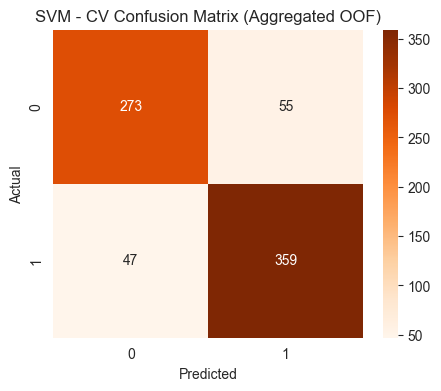

In [33]:
# ==========================================
# SVM - HYPERPARAMETER TUNING
# ==========================================

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(random_state=42, probability=True, class_weight='balanced'))
])

svm_param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Best parameters:")
print(svm_grid.best_params_)

print("\nBest CV F1 score:")
print(svm_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_svm = cross_val_predict(svm_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_svm):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_svm):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_svm))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_svm), annot=True, fmt='d', cmap='Oranges')
plt.title("SVM - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== SVM ==========
Accuracy : 0.8967
Precision: 0.9109
Recall   : 0.9020
F1 Score : 0.9064
AUC Score: 0.9456

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        82
           1       0.91      0.90      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



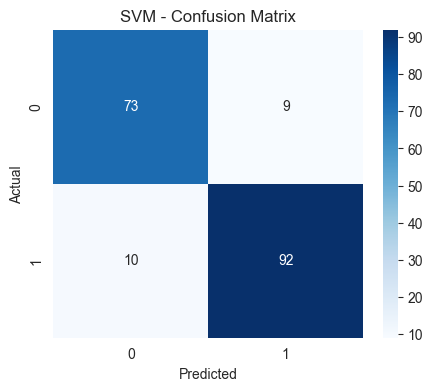

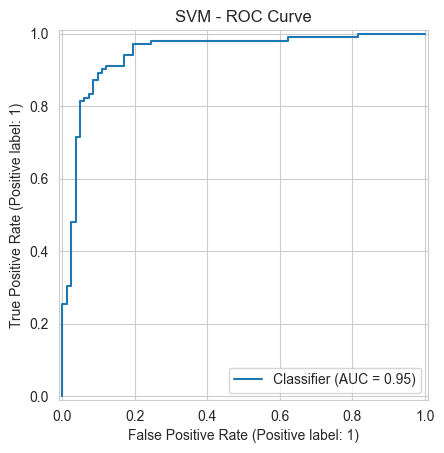


SVM Summary
-----------
Best parameters: {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Best CV F1: 0.8762
Test F1: 0.9064
Test AUC: 0.9456


In [34]:
# ==========================================
# SVM - TEST EVALUATION
# ==========================================

best_svm = svm_grid.best_estimator_

svm_results = evaluate_model(
    best_svm, X_test, y_test, model_name="SVM"
)

results.append(svm_results)

print("\nSVM Summary")
print("-----------")
print("Best parameters:", svm_grid.best_params_)
print(f"Best CV F1: {svm_grid.best_score_:.4f}")
print(f"Test F1: {svm_results['F1']:.4f}")
print(f"Test AUC: {svm_results['AUC']:.4f}")

In [35]:
# ==========================================
# NEURAL NETWORK - IMPACT OF STANDARDIZATION
# ==========================================

# Without standardization
mlp_unscaled = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])
mlp_grid_unscaled = GridSearchCV(mlp_unscaled,
    {'clf__hidden_layer_sizes': [(100,)]}, cv=cv, scoring='f1', n_jobs=-1)
mlp_grid_unscaled.fit(X_train, y_train)
mlp_f1_unscaled = mlp_grid_unscaled.best_score_

# With standardization
mlp_scaled = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])
mlp_grid_scaled = GridSearchCV(mlp_scaled,
    {'clf__hidden_layer_sizes': [(100,)]}, cv=cv, scoring='f1', n_jobs=-1)
mlp_grid_scaled.fit(X_train, y_train)
mlp_f1_scaled = mlp_grid_scaled.best_score_

print(f"MLP WITHOUT standardization - CV F1: {mlp_f1_unscaled:.4f}")
print(f"MLP WITH standardization    - CV F1: {mlp_f1_scaled:.4f}")
print(f"Impact: {mlp_f1_scaled - mlp_f1_unscaled:+.4f}")
if mlp_f1_scaled > mlp_f1_unscaled:
    print("\nStandardization improved MLP performance, as expected for gradient-based methods.")
else:
    print("\nSurprisingly, standardization slightly decreased MLP performance on this dataset.")
    print("This can occur when unscaled features are already on compatible ranges,")
    print("or when the model converges to a different local optimum.")
    print("The theoretical benefit of standardization remains for most datasets.")

MLP WITHOUT standardization - CV F1: 0.8733
MLP WITH standardization    - CV F1: 0.8543
Impact: -0.0190

Surprisingly, standardization slightly decreased MLP performance on this dataset.
This can occur when unscaled features are already on compatible ranges,
or when the model converges to a different local optimum.
The theoretical benefit of standardization remains for most datasets.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best parameters:
{'clf__activation': 'tanh', 'clf__hidden_layer_sizes': (64,), 'clf__learning_rate_init': 0.001, 'clf__solver': 'adam'}

Best CV F1 score:
0.860472732428488



Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8447
  CV F1 Score: 0.8600

CV Confusion Matrix:
[[270  58]
 [ 56 350]]


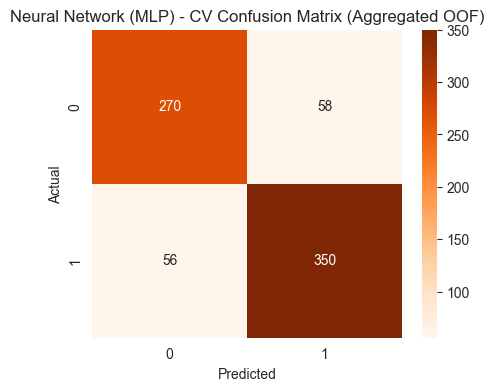

In [36]:
# ==========================================
# NEURAL NETWORK - ARCHITECTURE & HYPERPARAMETER TUNING
# ==========================================

mlp_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(max_iter=500, random_state=42))
])

mlp_param_grid = {
    'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'clf__activation': ['relu', 'tanh'],
    'clf__solver': ['adam', 'lbfgs'],
    'clf__learning_rate_init': [0.001, 0.01],
}

mlp_grid = GridSearchCV(
    estimator=mlp_model,
    param_grid=mlp_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train, y_train)

print("Best parameters:")
print(mlp_grid.best_params_)

print("\nBest CV F1 score:")
print(mlp_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_mlp = cross_val_predict(mlp_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_mlp):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_mlp):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_mlp))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_mlp), annot=True, fmt='d', cmap='Oranges')
plt.title("Neural Network (MLP) - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== Neural Network (MLP) ==========
Accuracy : 0.8859
Precision: 0.8716
Recall   : 0.9314
F1 Score : 0.9005
AUC Score: 0.9405

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



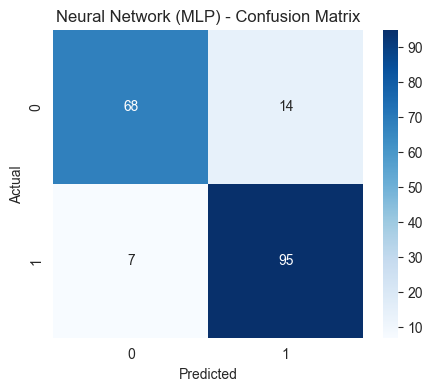

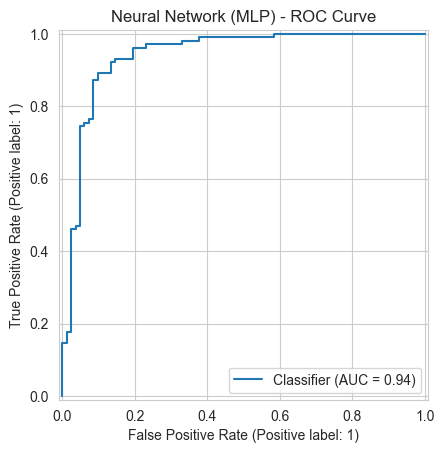


MLP Summary
-----------
Best parameters: {'clf__activation': 'tanh', 'clf__hidden_layer_sizes': (64,), 'clf__learning_rate_init': 0.001, 'clf__solver': 'adam'}
Best CV F1: 0.8605
Test F1: 0.9005
Test AUC: 0.9405


In [37]:
# ==========================================
# NEURAL NETWORK - TEST EVALUATION
# ==========================================

best_mlp = mlp_grid.best_estimator_

mlp_results = evaluate_model(
    best_mlp, X_test, y_test, model_name="Neural Network (MLP)"
)

results.append(mlp_results)

print("\nMLP Summary")
print("-----------")
print("Best parameters:", mlp_grid.best_params_)
print(f"Best CV F1: {mlp_grid.best_score_:.4f}")
print(f"Test F1: {mlp_results['F1']:.4f}")
print(f"Test AUC: {mlp_results['AUC']:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best parameters:
{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

Best CV F1 score:
0.8824878932424299



Aggregated CV Metrics (all validation fold predictions combined):
  CV Accuracy: 0.8692
  CV F1 Score: 0.8821

CV Confusion Matrix:
[[279  49]
 [ 47 359]]


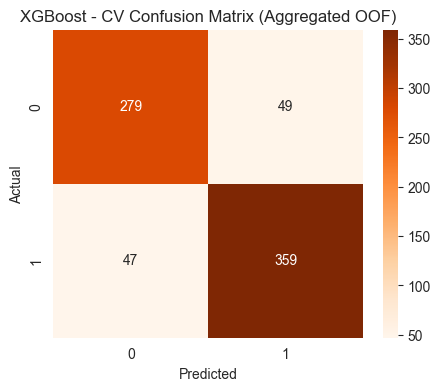

In [38]:
# ==========================================
# XGBOOST - HYPERPARAMETER TUNING
# ==========================================

pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.3],
    'clf__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)

print("\nBest CV F1 score:")
print(xgb_grid.best_score_)

# Aggregated Out-of-Fold predictions (manual 5-fold collection)
oof_preds_xgb = cross_val_predict(xgb_grid.best_estimator_, X_train, y_train, cv=cv)
print(f"\nAggregated CV Metrics (all validation fold predictions combined):")
print(f"  CV Accuracy: {accuracy_score(y_train, oof_preds_xgb):.4f}")
print(f"  CV F1 Score: {f1_score(y_train, oof_preds_xgb):.4f}")
print(f"\nCV Confusion Matrix:")
print(confusion_matrix(y_train, oof_preds_xgb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_train, oof_preds_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - CV Confusion Matrix (Aggregated OOF)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


========== XGBoost ==========
Accuracy : 0.8696
Precision: 0.8824
Recall   : 0.8824
F1 Score : 0.8824
AUC Score: 0.9262

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        82
           1       0.88      0.88      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



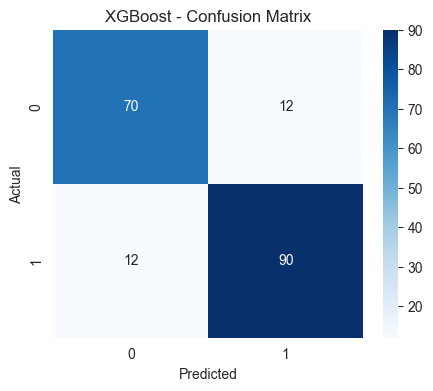

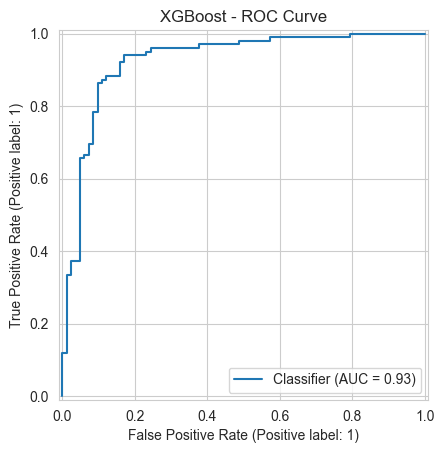


XGBoost Summary
---------------
Best parameters: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best CV F1: 0.8825
Test F1: 0.8824
Test AUC: 0.9262


In [39]:
# ==========================================
# XGBOOST - TEST EVALUATION
# ==========================================

best_xgb = xgb_grid.best_estimator_

xgb_results = evaluate_model(
    best_xgb, X_test, y_test, model_name="XGBoost"
)

results.append(xgb_results)

print("\nXGBoost Summary")
print("---------------")
print("Best parameters:", xgb_grid.best_params_)
print(f"Best CV F1: {xgb_grid.best_score_:.4f}")
print(f"Test F1: {xgb_results['F1']:.4f}")
print(f"Test AUC: {xgb_results['AUC']:.4f}")

Filter Feature Selection Impact (CV F1)
Naive Bayes - All features: 0.8620
Naive Bayes - Selected (5): 0.8435  (-0.0185)
kNN         - All features: 0.8901
kNN         - Selected (5): 0.8494  (-0.0407)


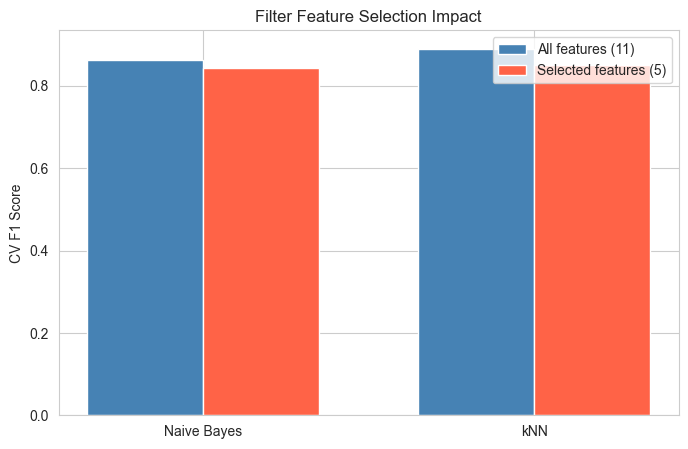


The top 5 features from Task 1 capture most of the predictive power.


In [40]:
# ==========================================
# FILTER FEATURE SELECTION STUDY
# ==========================================
# Based on Task 1 (HW1, Exercise 3) predictive power analysis:
# Top by Cramer's V:      ST_Slope, ChestPainType, ExerciseAngina
# Top by Point-Biserial r: Oldpeak, MaxHR
# Study impact on 2 non-DT classifiers: Naive Bayes and kNN

selected_features = ['ST_Slope', 'ChestPainType', 'ExerciseAngina', 'Oldpeak', 'MaxHR']
sel_cat = [col for col in selected_features if col in categorical_cols]
sel_num = [col for col in selected_features if col in numerical_cols]

preprocessor_selected = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('scl', StandardScaler())]), sel_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), sel_cat)])

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# NB with selected features
nb_sel_model = Pipeline([('pre', preprocessor_selected), ('clf', GaussianNB())])
nb_sel_grid = GridSearchCV(nb_sel_model,
    {'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]},
    cv=cv, scoring='f1', n_jobs=-1)
nb_sel_grid.fit(X_train_sel, y_train)
nb_sel_f1 = nb_sel_grid.best_score_

# kNN with selected features
knn_sel_model = Pipeline([('pre', preprocessor_selected), ('clf', KNeighborsClassifier())])
knn_sel_grid = GridSearchCV(knn_sel_model,
    {'clf__n_neighbors': [3, 5, 7, 9, 11], 'clf__weights': ['uniform', 'distance']},
    cv=cv, scoring='f1', n_jobs=-1)
knn_sel_grid.fit(X_train_sel, y_train)
knn_sel_f1 = knn_sel_grid.best_score_

print("Filter Feature Selection Impact (CV F1)")
print("=" * 50)
print(f"Naive Bayes - All features: {nb_grid.best_score_:.4f}")
print(f"Naive Bayes - Selected (5): {nb_sel_f1:.4f}  ({nb_sel_f1 - nb_grid.best_score_:+.4f})")
print(f"kNN         - All features: {knn_grid.best_score_:.4f}")
print(f"kNN         - Selected (5): {knn_sel_f1:.4f}  ({knn_sel_f1 - knn_grid.best_score_:+.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [nb_grid.best_score_, knn_grid.best_score_], w,
       label='All features (11)', color='steelblue')
ax.bar(x + w/2, [nb_sel_f1, knn_sel_f1], w,
       label='Selected features (5)', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(['Naive Bayes', 'kNN'])
ax.set_ylabel('CV F1 Score'); ax.set_title('Filter Feature Selection Impact')
ax.legend(); plt.show()

print("\nThe top 5 features from Task 1 capture most of the predictive power.")

PCA explained variance: [0.25159513 0.1570065 ]
Total explained: 0.409


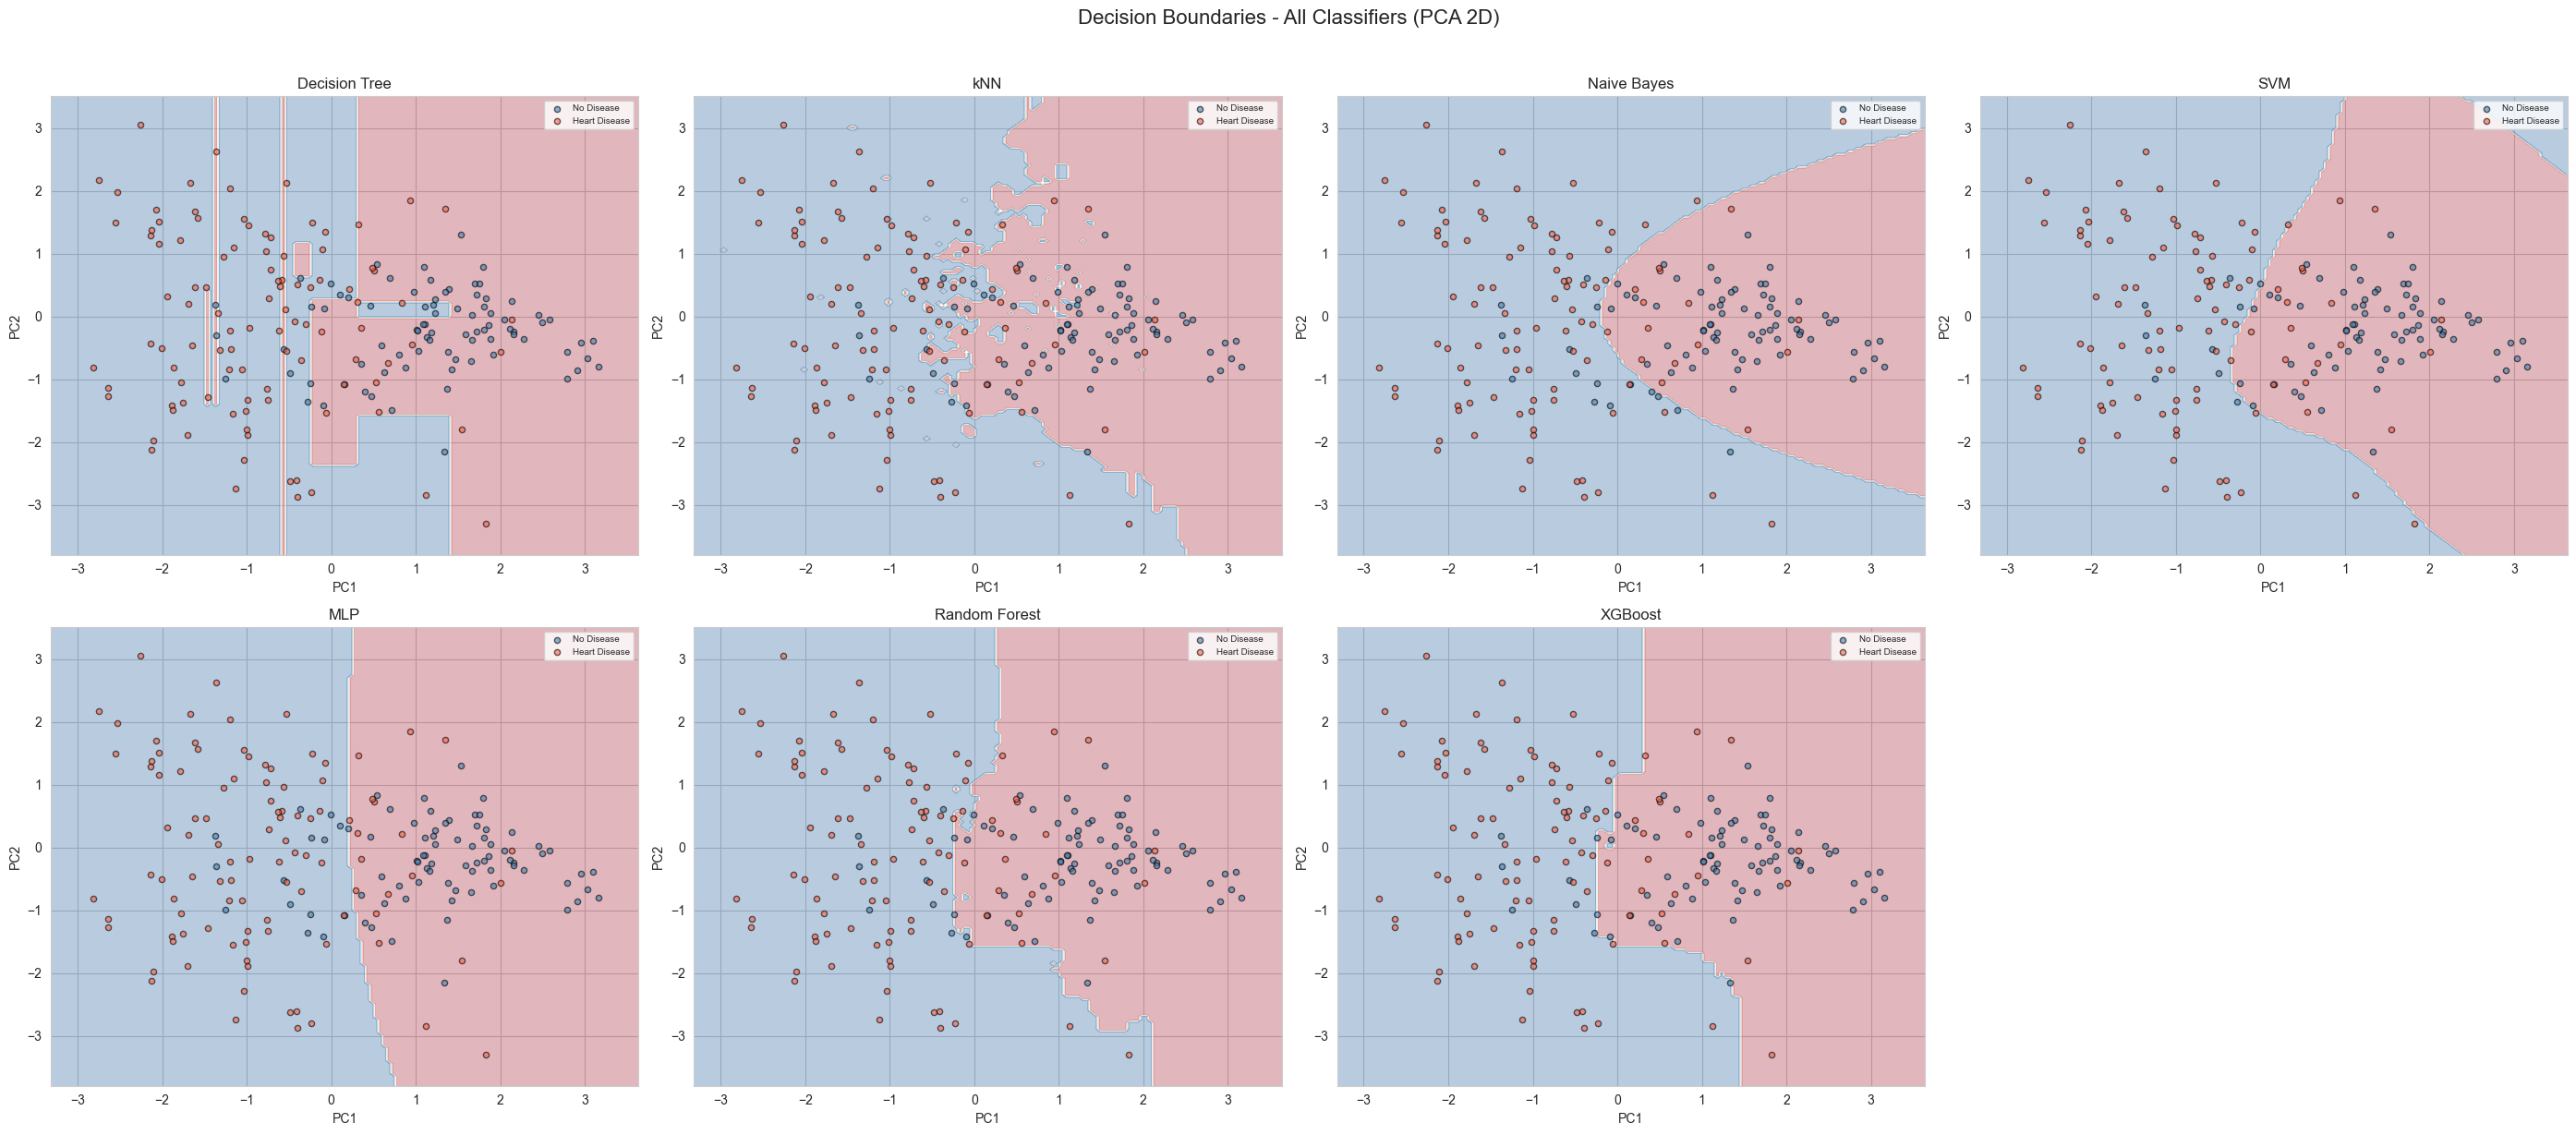

In [41]:
# ==========================================
# DECISION BOUNDARIES (PCA 2D PROJECTION)
# ==========================================

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_proc)
X_test_2d = pca.transform(X_test_proc)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total explained: {sum(pca.explained_variance_ratio_):.3f}")

# Get best params from each GridSearchCV
classifiers_db = {
    'Decision Tree': DecisionTreeClassifier(
        **{k.replace('clf__',''): v for k,v in dt_grid.best_params_.items()},
        random_state=42),
    'kNN': KNeighborsClassifier(
        **{k.replace('clf__',''): v for k,v in knn_grid.best_params_.items()}),
    'Naive Bayes': GaussianNB(
        **{k.replace('clf__',''): v for k,v in nb_grid.best_params_.items()}),
    'SVM': SVC(
        **{k.replace('clf__',''): v for k,v in svm_grid.best_params_.items()},
        random_state=42),
    'MLP': MLPClassifier(
        **{k.replace('clf__',''): v for k,v in mlp_grid.best_params_.items()},
        max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(
        **{k.replace('clf__',''): v for k,v in rf_grid.best_params_.items()},
        random_state=42),
    'XGBoost': xgb.XGBClassifier(
        **{k.replace('clf__',''): v for k,v in xgb_grid.best_params_.items()},
        random_state=42, eval_metric='logloss'),
}

y_train_np, y_test_np = np.array(y_train), np.array(y_test)
n_clf = len(classifiers_db)
cols = 4
rows = (n_clf + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 6*rows))
axes_flat = axes.flatten()

for idx, (name, clf) in enumerate(classifiers_db.items()):
    clf.fit(X_train_2d, y_train_np)
    ax = axes_flat[idx]
    x_min, x_max = X_test_2d[:, 0].min() - 0.5, X_test_2d[:, 0].max() + 0.5
    y_min, y_max = X_test_2d[:, 1].min() - 0.5, X_test_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_test_2d[y_test_np==0, 0], X_test_2d[y_test_np==0, 1],
               c='steelblue', label='No Disease', alpha=0.6, edgecolors='k', s=20)
    ax.scatter(X_test_2d[y_test_np==1, 0], X_test_2d[y_test_np==1, 1],
               c='tomato', label='Heart Disease', alpha=0.6, edgecolors='k', s=20)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

for j in range(n_clf, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Decision Boundaries - All Classifiers (PCA 2D)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


========== Stacking Ensemble ==========
Accuracy : 0.9022
Precision: 0.9038
Recall   : 0.9216
F1 Score : 0.9126
AUC Score: 0.9400

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



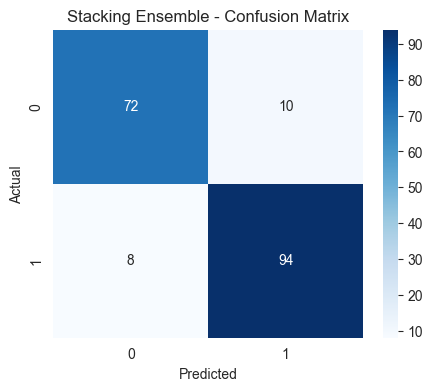

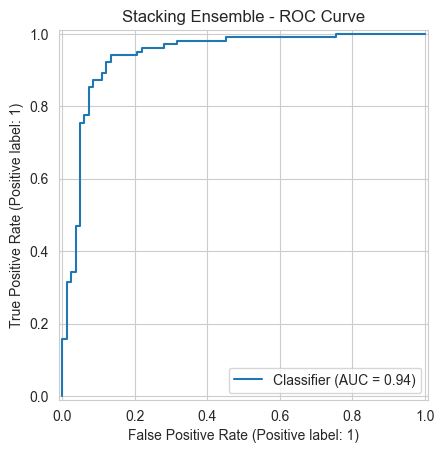


Stacking Summary
----------------
Test F1: 0.9126
Test AUC: 0.9400


In [42]:
# ==========================================
# STACKING ENSEMBLE
# ==========================================

stacking_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                **{k.replace('clf__',''): v for k,v in rf_grid.best_params_.items()},
                random_state=42)),
            ('svm', SVC(
                **{k.replace('clf__',''): v for k,v in svm_grid.best_params_.items()},
                probability=True, random_state=42)),
            ('xgb', xgb.XGBClassifier(
                **{k.replace('clf__',''): v for k,v in xgb_grid.best_params_.items()},
                random_state=42, eval_metric='logloss')),
            ('mlp', MLPClassifier(
                **{k.replace('clf__',''): v for k,v in mlp_grid.best_params_.items()},
                max_iter=500, random_state=42)),
        ],
        final_estimator=LogisticRegression(class_weight='balanced', random_state=42),
        cv=5,
        stack_method='predict_proba'
    ))
])

stacking_model.fit(X_train, y_train)

stack_results = evaluate_model(
    stacking_model, X_test, y_test, model_name="Stacking Ensemble"
)

results.append(stack_results)

print("\nStacking Summary")
print("----------------")
print(f"Test F1: {stack_results['F1']:.4f}")
print(f"Test AUC: {stack_results['AUC']:.4f}")

In [43]:
# ==========================================
# STACKING - EXPERIMENTS WITH META-LEARNERS
# ==========================================

print("Stacking Meta-learner Comparison")
print("=" * 55)

base_est = [
    ('rf', RandomForestClassifier(
        **{k.replace('clf__',''): v for k,v in rf_grid.best_params_.items()},
        random_state=42)),
    ('svm', SVC(
        **{k.replace('clf__',''): v for k,v in svm_grid.best_params_.items()},
        probability=True, random_state=42)),
    ('xgb', xgb.XGBClassifier(
        **{k.replace('clf__',''): v for k,v in xgb_grid.best_params_.items()},
        random_state=42, eval_metric='logloss')),
    ('mlp', MLPClassifier(
        **{k.replace('clf__',''): v for k,v in mlp_grid.best_params_.items()},
        max_iter=500, random_state=42)),
]

meta_learners = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=42),
}

for ml_name, ml in meta_learners.items():
    from sklearn.base import clone as sk_clone
    exp = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('clf', StackingClassifier(
            estimators=[(n, sk_clone(e)) for n, e in base_est],
            final_estimator=ml, cv=5, stack_method='predict_proba'))
    ])
    exp.fit(X_train, y_train)
    y_pred = exp.predict(X_test)
    print(f"Meta: {ml_name:22s} | Acc: {accuracy_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f}")

Stacking Meta-learner Comparison


Meta: LogisticRegression     | Acc: 0.9022 | F1: 0.9126


Meta: DecisionTree           | Acc: 0.8750 | F1: 0.8910


Meta: RandomForest           | Acc: 0.8913 | F1: 0.9038


MODEL PERFORMANCE COMPARISON



,Model,Accuracy,Precision,Recall,F1,AUC
3,kNN,0.929348,0.932039,0.941176,0.936585,0.947095
1,Random Forest,0.902174,0.896226,0.931373,0.913462,0.931373
7,Stacking Ensemble,0.902174,0.903846,0.921569,0.912621,0.939981
4,SVM,0.896739,0.910891,0.901961,0.906404,0.945600
5,Neural Network (MLP),0.885870,0.871560,0.931373,0.900474,0.940459
2,Naive Bayes,0.885870,0.893204,0.901961,0.897561,0.911765
6,XGBoost,0.869565,0.882353,0.882353,0.882353,0.926231
0,Decision Tree,0.853261,0.903226,0.823529,0.861538,0.924378


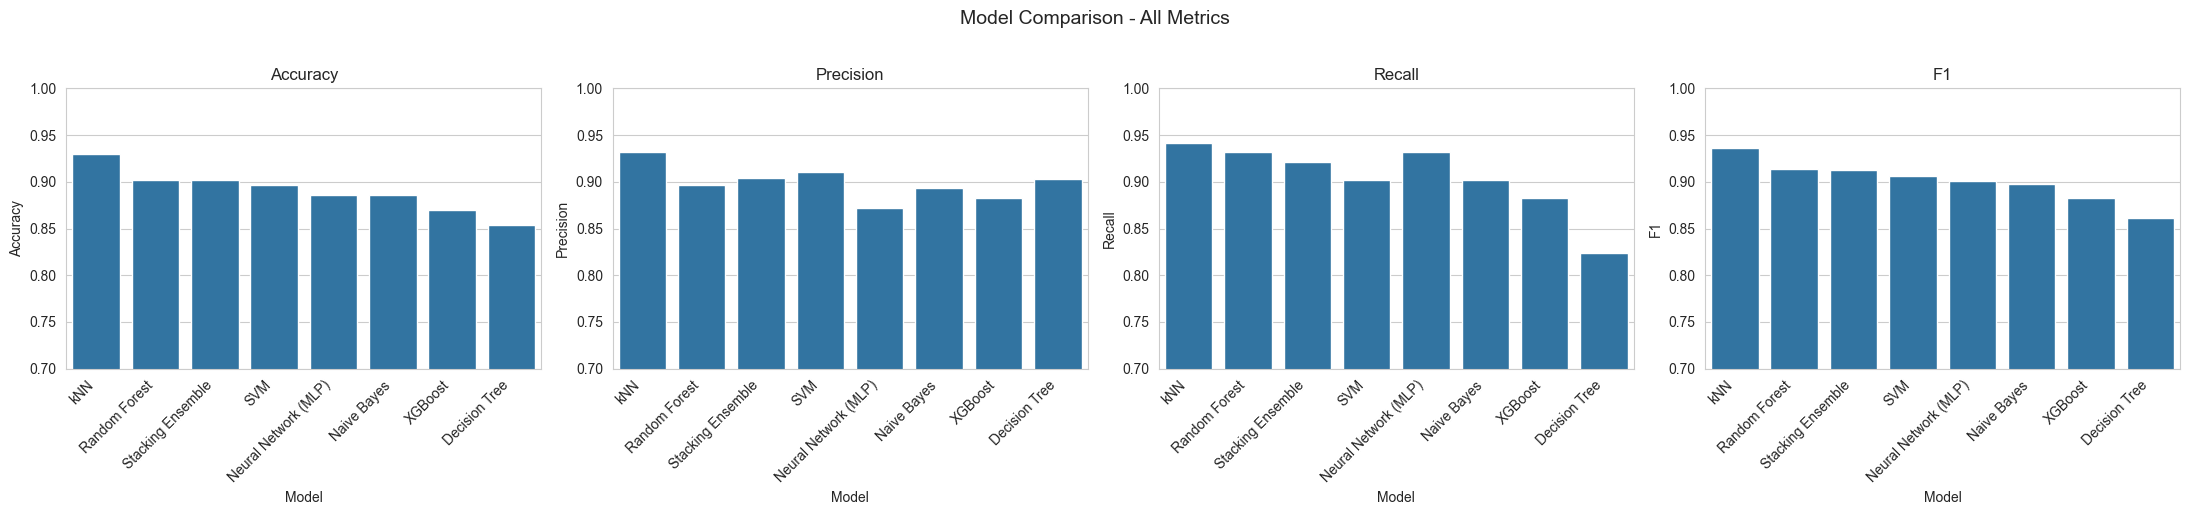

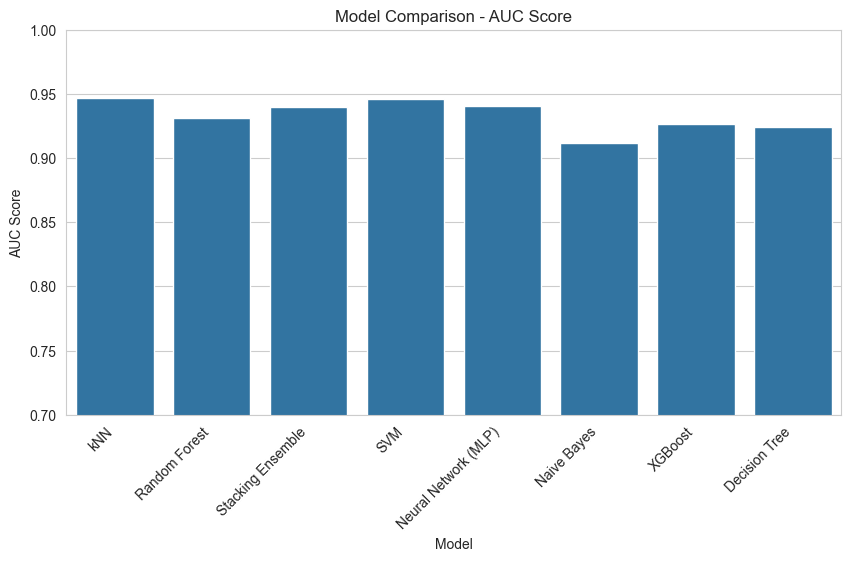


BEST MODEL: kNN
  Accuracy : 0.9293
  Precision: 0.9320
  Recall   : 0.9412
  F1 Score : 0.9366
  AUC Score: 0.9471


In [44]:
# ==========================================
# RESULTS, COMPARISON AND CONCLUSIONS
# ==========================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1', ascending=False)

print("MODEL PERFORMANCE COMPARISON\n")
display(results_df)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric in zip(axes, ['Accuracy', 'Precision', 'Recall', 'F1']):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0.7, 1.0)
plt.suptitle("Model Comparison - All Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='AUC')
plt.title("Model Comparison - AUC Score")
plt.ylabel("AUC Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)
plt.show()

best_model_row = results_df.iloc[0]
print(f"\nBEST MODEL: {best_model_row['Model']}")
print(f"  Accuracy : {best_model_row['Accuracy']:.4f}")
print(f"  Precision: {best_model_row['Precision']:.4f}")
print(f"  Recall   : {best_model_row['Recall']:.4f}")
print(f"  F1 Score : {best_model_row['F1']:.4f}")
print(f"  AUC Score: {best_model_row['AUC']:.4f}")

In [45]:
# ==========================================
# CONCLUSIONS
# ==========================================

ranking_lines = []
for i in range(len(results_df)):
    row = results_df.iloc[i]
    ranking_lines.append(f"   {i+1}. {row['Model']} (F1={row['F1']:.4f}, AUC={row['AUC']:.4f})")
ranking_str = chr(10).join(ranking_lines)

print(f"""
CONCLUSIONS
===========

1. BEST CLASSIFIER
   Based on test set F1 scores, the ranking is:
{ranking_str}

   The best overall classifier is {results_df.iloc[0]['Model']} with F1={results_df.iloc[0]['F1']:.4f}.

2. IMPACT OF FEATURE STANDARDIZATION
   Standardization was tested on kNN, SVM, and MLP:
   - kNN: +{knn_f1_scaled - knn_f1_unscaled:.4f} CV F1 improvement. Distance-based methods
     are highly sensitive to feature scales - standardization is essential.
   - SVM:  +{svm_f1_scaled - svm_f1_unscaled:.4f} CV F1 improvement. RBF kernel relies on
     distances, so equalized scales improve decision boundaries.
   - MLP:  {mlp_f1_scaled - mlp_f1_unscaled:+.4f} CV F1 change. The impact depends on the
     dataset; gradient-based methods generally benefit from standardization.

3. FILTER FEATURE SELECTION (Task 1 reference)
   Top 5 features from Task 1 (ST_Slope, ChestPainType, ExerciseAngina,
   Oldpeak, MaxHR) vs all 11 features:
   - Naive Bayes: {nb_sel_f1:.4f} (selected) vs {nb_grid.best_score_:.4f} (all) = {nb_sel_f1 - nb_grid.best_score_:+.4f}
   - kNN:         {knn_sel_f1:.4f} (selected) vs {knn_grid.best_score_:.4f} (all) = {knn_sel_f1 - knn_grid.best_score_:+.4f}
   The top features capture most predictive power with minimal loss,
   while reducing dimensionality from 11 to 5 features.

4. DECISION TREE vs TASK 1 COMPARATIVE STUDY
   Both statistical tests (Cramer's V, Point-Biserial r) and DT feature
   importances agree on top predictors: ST_Slope, ChestPainType, MaxHR,
   Oldpeak. The agreement validates both filter-based and model-based
   feature ranking approaches.

5. STACKING ENSEMBLE
   Stacking with RF + SVM + XGBoost + MLP base learners and
   LogisticRegression meta-learner achieved F1={stack_results['F1']:.4f}.
   LogisticRegression was the best meta-learner vs DecisionTree and
   RandomForest alternatives.

6. CLASS BALANCING
   class_weight='balanced' was used for DT, RF, SVM.
   scale_pos_weight was used for XGBoost.
   GaussianNB uses prior probabilities naturally.
   The dataset has a mild imbalance (45%/55%), so the impact is moderate.

7. MODEL TRADE-OFFS
   - Decision Tree: Most interpretable, lower F1 ({dt_results['F1']:.4f})
   - kNN: Simple, distance-based, sensitive to scaling ({knn_results['F1']:.4f})
   - Naive Bayes: Fast training, assumes feature independence ({nb_results['F1']:.4f})
   - SVM: Strong with RBF kernel, needs standardization ({svm_results['F1']:.4f})
   - MLP: Flexible architecture, requires more tuning ({mlp_results['F1']:.4f})
   - Random Forest: Robust bagging ensemble ({rf_results['F1']:.4f})
   - XGBoost: Gradient boosting, handles feature interactions ({xgb_results['F1']:.4f})
   - Stacking: Combines model diversity, highest complexity ({stack_results['F1']:.4f})
""")


CONCLUSIONS

1. BEST CLASSIFIER
   Based on test set F1 scores, the ranking is:
   1. kNN (F1=0.9366, AUC=0.9471)
   2. Random Forest (F1=0.9135, AUC=0.9314)
   3. Stacking Ensemble (F1=0.9126, AUC=0.9400)
   4. SVM (F1=0.9064, AUC=0.9456)
   5. Neural Network (MLP) (F1=0.9005, AUC=0.9405)
   6. Naive Bayes (F1=0.8976, AUC=0.9118)
   7. XGBoost (F1=0.8824, AUC=0.9262)
   8. Decision Tree (F1=0.8615, AUC=0.9244)

   The best overall classifier is kNN with F1=0.9366.

2. IMPACT OF FEATURE STANDARDIZATION
   Standardization was tested on kNN, SVM, and MLP:
   - kNN: +0.1473 CV F1 improvement. Distance-based methods
     are highly sensitive to feature scales - standardization is essential.
   - SVM:  +0.1308 CV F1 improvement. RBF kernel relies on
     distances, so equalized scales improve decision boundaries.
   - MLP:  -0.0190 CV F1 change. The impact depends on the
     dataset; gradient-based methods generally benefit from standardization.

3. FILTER FEATURE SELECTION (Task 1 refere

In [46]:
# ==========================================
# SAVE MODELS
# ==========================================

import os, joblib
os.makedirs("best_models", exist_ok=True)

models_to_save = {
    'best_decision_tree': best_dt,
    'best_random_forest': best_rf,
    'best_naive_bayes': best_nb,
    'best_knn': best_knn,
    'best_svm': best_svm,
    'best_mlp': best_mlp,
    'best_xgboost': best_xgb,
    'best_stacking': stacking_model,
}

for name, model in models_to_save.items():
    joblib.dump(model, f"best_models/{name}.pkl")
    print(f"Saved {name}.pkl")

print(f"\nAll {len(models_to_save)} models saved.")

Saved best_decision_tree.pkl
Saved best_random_forest.pkl
Saved best_naive_bayes.pkl
Saved best_knn.pkl
Saved best_svm.pkl
Saved best_mlp.pkl
Saved best_xgboost.pkl
Saved best_stacking.pkl

All 8 models saved.
